Perturb

   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


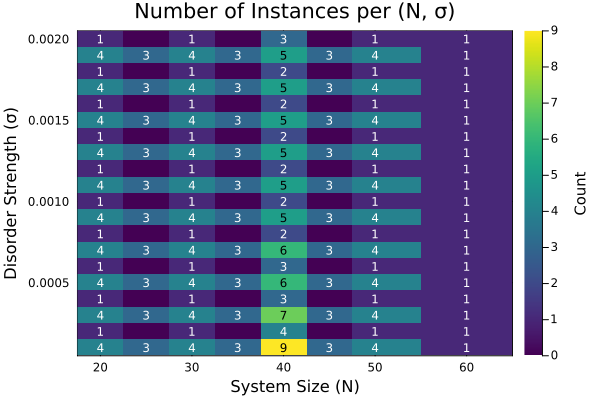

In [ ]:
using Plots, ITensorMPS, ITensors
include("../params.jl")
include("./saving.jl")

function plot_instance_heatmap()
    # Define your parameters
    Ns = [20, 25, 30, 35, 40, 45, 50, 60]
    σs = collect(0.0001:0.0001:0.002)

    # Initialize a matrix to store the counts (Rows = σ, Columns = N)
    counts = zeros(Int, length(σs), length(Ns))

    # Standard system parameters to resolve the filepath
    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )
    fp_suffix = extract_filename_from_system_params(system_params)

    # Loop over all combinations
    for (j, N) in enumerate(Ns)
        for (i, σ) in enumerate(σs)

            # Format sigma to avoid trailing float precision issues in the filepath
            σ_val = round(σ, digits=4)
            fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ_val)_$(fp_suffix).hd5")

            # Check if the file exists before querying
            if isfile(fp)
                # CRITICAL: load_psi=false makes this instantaneous!
                runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ_val);
                                           load_psi=false, instance_selection=:all)
                counts[i, j] = length(runs)
            else
                counts[i, j] = 0
            end
        end
    end

    # Plot the heatmap
    p = heatmap(Ns, σs, counts,
                title="Number of Instances per (N, σ)",
                xlabel="System Size (N)",
                ylabel="Disorder Strength (σ)",
                c=:viridis,            # Nice colormap
                colorbar_title="Count",
                framestyle=:box)

    # Add the text annotations inside the heatmap cells
    for (j, N) in enumerate(Ns)
        for (i, σ) in enumerate(σs)
            count_val = counts[i, j]
            # Change text color based on background darkness for readability
            txt_color = count_val > maximum(counts)/2 ? :black : :white

            # Only annotate if the count is greater than 0 to keep the plot clean
            if count_val > 0
                annotate!(p, N, σ, text(string(count_val), 8, txt_color))
            end
        end
    end

    display(p)
end

# Call the function
plot_instance_heatmap()